Fecom Inc. là công ty thương mại điện tử có trụ sở tại Berlin, Đức. Từ năm 2022 đến 2024, công ty đã ghi nhận 99.441 đơn hàng từ 102.727 khách hàng duy nhất và theo dõi giao dịch của 3.095 người bán. Bộ dữ liệu chứa thông tin về:

- Đơn hàng (Orders): Thông tin về trạng thái đơn hàng, thời gian mua, duyệt, giao hàng...
- Khách hàng (Customer_List): Thông tin về ngày đăng ký, ngày đặt hàng đầu tiên, địa chỉ, độ tuổi, giới tính...
- Chi tiết đơn hàng (Order_Items): Danh sách sản phẩm, giá, phí vận chuyển, ngày giao hàng dự kiến...
- Sản phẩm (Products): Thông tin về danh mục, kích thước, trọng lượng sản phẩm...
- Đánh giá đơn hàng (Order_Reviews): Điểm đánh giá, tiêu đề và nội dung bình luận, thời gian đánh giá...

Dữ liệu này đến từ 338 thành phố tại 28 quốc gia, với 32.951 sản phẩm thuộc 72 danh mục khác nhau. Mục tiêu của bài thực hành là sử dụng Spark DataFrame để thực hiện các phân tích bán hàng và tiếp thị.

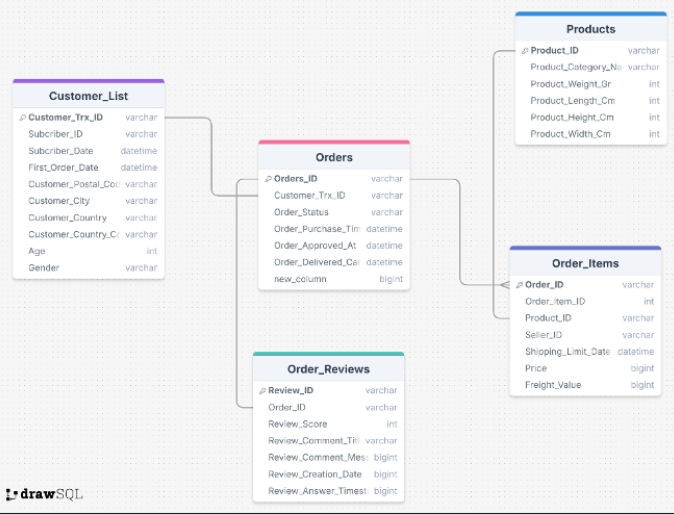
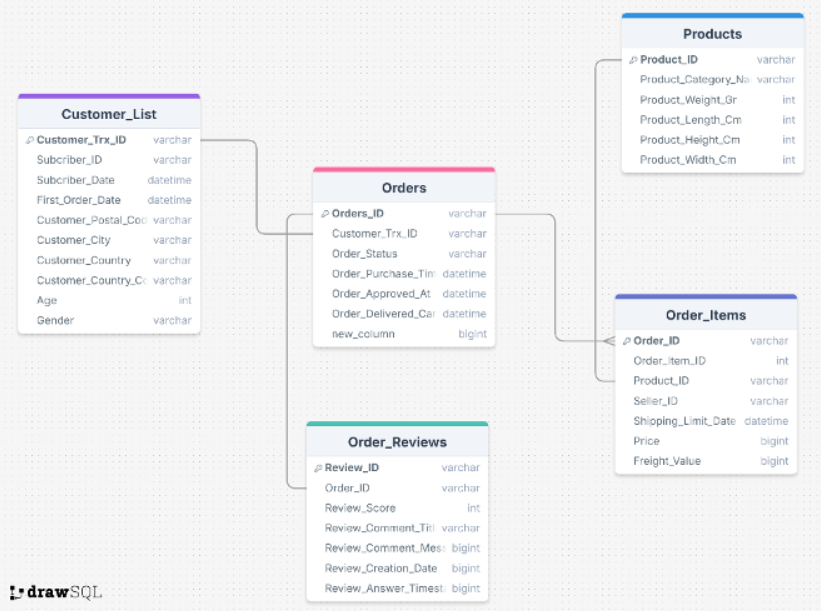

### Hãy sử dụng Spark DataFrame thực hiện các yêu cầu bên dưới:

1.	Hãy đọc dữ liệu từ các file csv, sử dụng tự suy ra kiểu dữ liệu cho mỗi cột.
2.	Thống kê tổng số đơn hàng, số lượng khách hàng và người bán.
3.	Phân tích số lượng đơn hàng theo quốc gia, sắp xếp theo thứ tự giảm dần.
4.	Phân tích số lượng đơn hàng nhóm theo năm, tháng đặt hàng (Hiển thị theo năm tăng dần, tháng giảm dần)
5.	Thống kê điểm đánh giá trung bình, số lượng đánh giá theo từng mức (ví dụ: 1 đến 5).
Lưu ý: Cần xử lý các giá trị ngoại lệ và NULL trong cột Review_Score

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, count, avg, sum as _sum, datediff, to_date

## Khởi tạo Spark Session

In [8]:
spark = SparkSession.builder \
    .appName("Fecom_Data_Analysis") \
    .getOrCreate()


## 1. Đọc dữ liệu từ các file csv


In [9]:
orders_df = spark.read.option("delimiter", ";").option("header", True).option("inferSchema", True).csv("data/Orders.csv")
customer_list_df = spark.read.option("delimiter", ";").option("header", True).option("inferSchema", True).csv("data/Customer_List.csv")
order_items_df = spark.read.option("delimiter", ";").option("header", True).option("inferSchema", True).csv("data/Order_Items.csv")
products_df = spark.read.option("delimiter", ";").option("header", True).option("inferSchema", True).csv("data/Products.csv")
order_reviews_df = spark.read.option("delimiter", ";") \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("multiLine", True) \
    .option("escape", '"') \
    .csv("data/Order_Reviews.csv")

## 2. Thống kê tổng số đơn hàng, số lượng khách hàng và người bán

In [10]:
total_orders = orders_df.select("Order_ID").distinct().count()
total_customers = customer_list_df.select("Customer_Trx_ID").distinct().count()
total_sellers = order_items_df.select("Seller_ID").distinct().count()

print(f"Tổng số đơn hàng: {total_orders}")
print(f"Tổng số lượng khách hàng: {total_customers}")
print(f"Tổng số lượng người bán: {total_sellers}")

Tổng số đơn hàng: 99441
Tổng số lượng khách hàng: 99442
Tổng số lượng người bán: 3095


## 3. Phân tích số lượng đơn hàng theo quốc gia, sắp xếp giảm dần

In [11]:
orders_customers_df = orders_df.join(customer_list_df, "Customer_Trx_ID", "inner")

orders_by_country = orders_customers_df.groupBy("Customer_Country") \
    .agg(count("Order_ID").alias("total_orders")) \
    .orderBy(col("total_orders").desc())

table_string = orders_by_country.toPandas().to_string(index=False)
file_name = "bt3_result.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write("THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO QUỐC GIA\n")
    f.write("=" * 45 + "\n")
    f.write(table_string)

print("Số lượng đơn hàng theo quốc gia:")
orders_by_country.show()

Số lượng đơn hàng theo quốc gia:
+----------------+------------+
|Customer_Country|total_orders|
+----------------+------------+
|         Germany|       41754|
|          France|       12848|
|     Netherlands|       11629|
|         Belgium|        5464|
|         Austria|        5043|
|     Switzerland|        3640|
|  United Kingdom|        3382|
|          Poland|        2139|
|         Czechia|        2034|
|           Italy|        2025|
|           Spain|        1651|
|        Portugal|        1336|
|          Sweden|         975|
|         Denmark|         905|
|          Serbia|         746|
|          Norway|         716|
|        Slovakia|         534|
|        Slovenia|         495|
|          Turkey|         485|
|          Greece|         412|
+----------------+------------+
only showing top 20 rows


# 4. Phân tích số lượng đơn hàng nhóm theo năm, tháng đặt hàng


In [12]:
orders_by_time = orders_df \
    .withColumn("order_year", year(col("Order_Purchase_Timestamp"))) \
    .withColumn("order_month", month(col("Order_Purchase_Timestamp"))) \
    .groupBy("order_year", "order_month") \
    .agg(count("Order_ID").alias("total_orders")) \
    .orderBy(col("order_year").asc(), col("order_month").desc())

time_table_string = orders_by_time.toPandas().to_string(index=False)
file_name = "bt4_result.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write("THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO NĂM VÀ THÁNG\n")
    f.write("=" * 50 + "\n")
    f.write(time_table_string)

print("Số lượng đơn hàng theo năm và tháng:")
orders_by_time.show()

Số lượng đơn hàng theo năm và tháng:
+----------+-----------+------------+
|order_year|order_month|total_orders|
+----------+-----------+------------+
|      2022|         12|           1|
|      2022|         10|         324|
|      2022|          9|           4|
|      2023|         12|        5673|
|      2023|         11|        7544|
|      2023|         10|        4631|
|      2023|          9|        4285|
|      2023|          8|        4331|
|      2023|          7|        4026|
|      2023|          6|        3245|
|      2023|          5|        3700|
|      2023|          4|        2404|
|      2023|          3|        2682|
|      2023|          2|        1780|
|      2023|          1|         800|
|      2024|         10|           4|
|      2024|          9|          16|
|      2024|          8|        6512|
|      2024|          7|        6292|
|      2024|          6|        6167|
+----------+-----------+------------+
only showing top 20 rows


## 5. Thống kê điểm đánh giá trung bình, số lượng đánh giá theo từng mức


In [13]:
safe_reviews_df = order_reviews_df.withColumn("Review_Score_Safe", col("Review_Score").cast("int"))

cleaned_reviews_df = safe_reviews_df.filter(col("Review_Score_Safe").isNotNull() & col("Review_Score_Safe").between(1, 5))

avg_review_score = cleaned_reviews_df.select(avg("Review_Score_Safe").alias("avg_score")).collect()[0]["avg_score"]
print(f"Điểm đánh giá trung bình: {avg_review_score:.2f}")

reviews_by_score = cleaned_reviews_df.groupBy("Review_Score_Safe") \
    .agg(count("*").alias("count_reviews")) \
    .orderBy(col("Review_Score_Safe").desc())

print("Số lượng đánh giá theo từng mức (1 - 5):")
reviews_by_score.show()

Điểm đánh giá trung bình: 4.09
Số lượng đánh giá theo từng mức (1 - 5):
+-----------------+-------------+
|Review_Score_Safe|count_reviews|
+-----------------+-------------+
|                5|        57328|
|                4|        19141|
|                3|         8179|
|                2|         3151|
|                1|        11424|
+-----------------+-------------+



### Chọn 3 trong các câu sau để làm:

6.  Tính doanh thu (giá sản phẩm + phí vận chuyển) trong năm 2024 và nhóm theo danh mục sản phẩm
7.  Xác định sản phẩm có số lượng bán ra cao nhất và tính điểm đánh giá trung bình cho từng sản phẩm
8.  Tính toán hiệu số giữa ngày giao hàng thực tế (Order_Delivered_Carrier_Date) và ngày giao hàng dự kiến (ví dụ: Shipping_Limit_Date từ bảng Order_Items) để đánh giá hiệu suất giao hàng.
9.  Nhóm khách hàng dựa trên số lượng đơn hàng, giá trị trung bình của đơn hàng và tần suất mua sắm.
10. Xếp hạng các seller dựa trên tổng doanh thu và số lượng đơn hàng bán được.


## 6. Tính doanh thu (giá sản phẩm + phí vận chuyển) trong năm 2024 và nhóm theo danh mục sản phẩm

In [14]:
orders_2024 = orders_df.filter(year(col("Order_Purchase_Timestamp")) == 2024)

revenue_df = orders_2024.join(order_items_df, "Order_ID", "inner") \
                        .join(products_df, "Product_ID", "inner")

revenue_by_category = revenue_df.withColumn("Revenue", col("Price") + col("Freight_Value")) \
    .groupBy("Product_Category_Name") \
    .agg(_sum("Revenue").alias("Total_Revenue_2024")) \
    .orderBy(col("Total_Revenue_2024").desc())

revenue_table_string = revenue_by_category.toPandas().to_string(index=False)
file_name = "bt6_result.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write("DOANH THU NĂM 2024 THEO DANH MỤC SẢN PHẨM\n")
    f.write("=" * 60 + "\n")
    f.write(revenue_table_string)

print("Doanh thu năm 2024 theo danh mục sản phẩm:")
revenue_by_category.show()

Doanh thu năm 2024 theo danh mục sản phẩm:
+---------------------+------------------+
|Product_Category_Name|Total_Revenue_2024|
+---------------------+------------------+
|        Health_Beauty|  885191.119999997|
|        Watches_Gifts|  771986.750000001|
|       Bed_Bath_Table|  650794.700000002|
|       Sports_Leisure| 621999.3399999994|
| Computers_Accesso...| 594771.0400000002|
|           Housewares| 491576.9600000012|
|      Furniture_Decor| 476466.1300000007|
|                 Auto| 404210.5700000002|
|                 Baby| 299052.5599999998|
|           Cool_Stuff| 273910.0500000001|
|         Garden_Tools|259068.31999999983|
|            Telephony| 217452.1299999995|
|            Perfumery|204562.53999999992|
|                 Toys|200634.07000000007|
|     Office_Furniture| 181745.7300000001|
|           Stationery|164743.84999999986|
|             Pet_Shop|152804.94000000012|
| Construction_Tool...|141187.33999999985|
|          Electronics| 134265.4499999999|
|  Musical_

## 7.  Xác định sản phẩm có số lượng bán ra cao nhất và tính điểm đánh giá trung bình cho từng sản phẩm


In [15]:
product_sales = order_items_df.groupBy("Product_ID") \
    .agg(count("*").alias("Total_Sold"))

items_reviews_df = order_items_df.join(cleaned_reviews_df, "Order_ID", "inner")

avg_score_per_product = items_reviews_df.groupBy("Product_ID") \
    .agg(
        avg("Review_Score_Safe").alias("Avg_Review_Score"),
        count("*").alias("Total_Reviews")
    )

top_selling_with_reviews = product_sales.join(avg_score_per_product, "Product_ID", "left") \
    .orderBy(col("Total_Sold").desc())

top_selling_string = top_selling_with_reviews.toPandas().to_string(index=False)
file_name = "bt7_result.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write("TOP SẢN PHẨM BÁN CHẠY NHẤT VÀ ĐIỂM ĐÁNH GIÁ TRUNG BÌNH\n")
    f.write("=" * 80 + "\n")
    f.write(top_selling_string)

print("Top sản phẩm bán chạy nhất và điểm đánh giá trung bình:")
top_selling_with_reviews.show(truncate=False)

Top sản phẩm bán chạy nhất và điểm đánh giá trung bình:
+--------------------------------+----------+------------------+-------------+
|Product_ID                      |Total_Sold|Avg_Review_Score  |Total_Reviews|
+--------------------------------+----------+------------------+-------------+
|aca2eb7d00ea1a7b8ebd4e68314663af|527       |4.019083969465649 |524          |
|99a4788cb24856965c36a24e339b6058|488       |3.8983402489626555|482          |
|422879e10f46682990de24d770e7f83d|484       |3.9465020576131686|486          |
|389d119b48cf3043d311335e499d9c6b|392       |4.117647058823529 |391          |
|368c6c730842d78016ad823897a372db|388       |3.922680412371134 |388          |
|53759a2ecddad2bb87a079a1f1519f73|373       |3.868632707774799 |373          |
|d1c427060a0f73f6b889a5c7c61f2ac4|343       |4.194117647058824 |340          |
|53b36df67ebb7c41585e8d54d6772e08|323       |4.190625          |320          |
|154e7e31ebfa092203795c972e5804a6|281       |4.315068493150685 |292        

## 8. Tính toán hiệu số giữa ngày giao hàng thực tế (Order_Delivered_Carrier_Date) và ngày giao hàng dự kiến (ví dụ: Shipping_Limit_Date từ bảng Order_Items) để đánh giá hiệu suất giao hàng.

In [16]:
delivery_df = orders_df.join(order_items_df, "Order_ID", "inner")

delivery_performance = delivery_df \
    .withColumn("Actual_Date", to_date(col("Order_Delivered_Carrier_Date"))) \
    .withColumn("Expected_Date", to_date(col("Shipping_Limit_Date"))) \
    .withColumn("Delivery_Diff_Days", datediff(col("Actual_Date"), col("Expected_Date"))) \
    .select("Order_ID", "Product_ID", "Actual_Date", "Expected_Date", "Delivery_Diff_Days")

sample_delivery = delivery_performance.filter(col("Delivery_Diff_Days").isNotNull())
delivery_table_string = sample_delivery.toPandas().to_string(index=False)

file_name = "bt8_result.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write("HIỆU SUẤT GIAO HÀNG (SỚM/TRỄ HẠN)\n")
    f.write("Ghi chú: Số ngày chênh lệch: Âm = Giao sớm, 0 = Đúng hạn, Dương = Giao trễ\n")
    f.write("=" * 80 + "\n")
    f.write(delivery_table_string)

print("Hiệu suất giao hàng (Số ngày chênh lệch: Âm = Sớm, Dương = Trễ):")
delivery_performance.filter(col("Delivery_Diff_Days").isNotNull()).show(10, truncate=False)

Hiệu suất giao hàng (Số ngày chênh lệch: Âm = Sớm, Dương = Trễ):
+--------------------------------+--------------------------------+-----------+-------------+------------------+
|Order_ID                        |Product_ID                      |Actual_Date|Expected_Date|Delivery_Diff_Days|
+--------------------------------+--------------------------------+-----------+-------------+------------------+
|00010242fe8c5a6d1ba2dd792cb16214|4244733e06e7ecb4970a6e2683c13e61|2023-09-19 |2023-09-19   |0                 |
|00018f77f2f0320c557190d7a144bdd3|e5f2d52b802189ee658865ca93d83a8f|2023-05-04 |2023-05-03   |1                 |
|000229ec398224ef6ca0657da4fc703e|c777355d18b72b67abbeef9df44fd0fd|2024-01-16 |2024-01-18   |-2                |
|00024acbcdf0a6daa1e931b038114c75|7634da152a4610f1595efa32f14722fc|2024-08-10 |2024-08-15   |-5                |
|00042b26cf59d7ce69dfabb4e55b4fd9|ac6c3623068f30de03045865e4e10089|2023-02-16 |2023-02-13   |3                 |
|00048cc3ae777c65dbb7d2a0634bc1